# Develop a Decision Tree Classification Model and Classify a New Sample

#### 1. Load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../ML Data.csv', dtype={'ROLL NO.': str})
df.columns = df.columns.str.strip()  # remove stray leading/trailing spaces from headers
print(df.head())
print(df.shape)

       ROLL NO. GENDER  SOFTWARE ENGINEER   TOC  COMPUTER NETWORK  \
0  240104010001      M               30.0  30.0              30.0   
1  240104010002      F               30.0  40.0              45.0   
2  240104010003      M               38.0  38.0              38.0   
3  240104010004      M               59.0  55.0              57.0   
4  240104010005      M               30.0  30.0              30.0   

   MACHINE LEARNING  DATA WAREHOUSE GRADE RESULT  
0              30.0            30.0     C   PASS  
1              40.0            35.0     B   Pass  
2              38.0            38.0     B   Pass  
3              58.0            54.0     A   pass  
4              30.0            30.0     C   Pass  
(86, 9)


#### 2. Clean the data

In [2]:
numeric_cols = ['SOFTWARE ENGINEER', 'TOC', 'COMPUTER NETWORK', 'MACHINE LEARNING', 'DATA WAREHOUSE']

df['GENDER'] = df['GENDER'].str.strip().str.upper()
df['RESULT'] = df['RESULT'].str.strip().str.upper()
df['GRADE'] = df['GRADE'].str.strip().str.upper()

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

for col in ['GENDER', 'RESULT', 'GRADE']:
    df[col] = df[col].fillna(df[col].mode()[0])

df = df.dropna(subset=['ROLL NO.'])
print(df.isnull().sum())
print("\nRESULT value counts:")
print(df['RESULT'].value_counts())

ROLL NO.             0
GENDER               0
SOFTWARE ENGINEER    0
TOC                  0
COMPUTER NETWORK     0
MACHINE LEARNING     0
DATA WAREHOUSE       0
GRADE                0
RESULT               0
dtype: int64

RESULT value counts:
RESULT
PASS         66
FAIL          4
DISCHARGE     1
Name: count, dtype: int64


#### 3. Define target (y)
Predict **RESULT** from the subject marks. Any class with fewer than 2 samples is dropped, since a model can't meaningfully learn or be evaluated on a single example.

In [3]:
MIN_SAMPLES_PER_CLASS = 2

class_counts = df['RESULT'].value_counts()
rare_classes = class_counts[class_counts < MIN_SAMPLES_PER_CLASS].index.tolist()

if rare_classes:
    print(f"Dropping rare class(es) with < {MIN_SAMPLES_PER_CLASS} samples: {rare_classes}")
    df = df[~df['RESULT'].isin(rare_classes)]

print(df['RESULT'].value_counts())

Dropping rare class(es) with < 2 samples: ['DISCHARGE']
RESULT
PASS    66
FAIL     4
Name: count, dtype: int64


#### 4. Encode target and define features

In [4]:
from sklearn.preprocessing import LabelEncoder

le_result = LabelEncoder()
df['RESULT_ENCODED'] = le_result.fit_transform(df['RESULT'])
print(dict(zip(le_result.classes_, le_result.transform(le_result.classes_))))

X = df[numeric_cols]
y = df['RESULT_ENCODED']

{'FAIL': np.int64(0), 'PASS': np.int64(1)}


#### 5. Train-test split
Decision Trees don't require feature scaling — splits are based on threshold comparisons, not distances.

In [5]:
from sklearn.model_selection import train_test_split

# Use stratify only if every remaining class has enough samples for it
min_class_count = y.value_counts().min()
stratify_arg = y if min_class_count >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=stratify_arg
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (56, 5)
Test shape: (14, 5)


#### 6. Train the Decision Tree Classifier

In [6]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in

#### 7. Visualize the tree
`max_depth=4` keeps the tree readable — remove it for full depth, at the cost of a much bigger diagram.

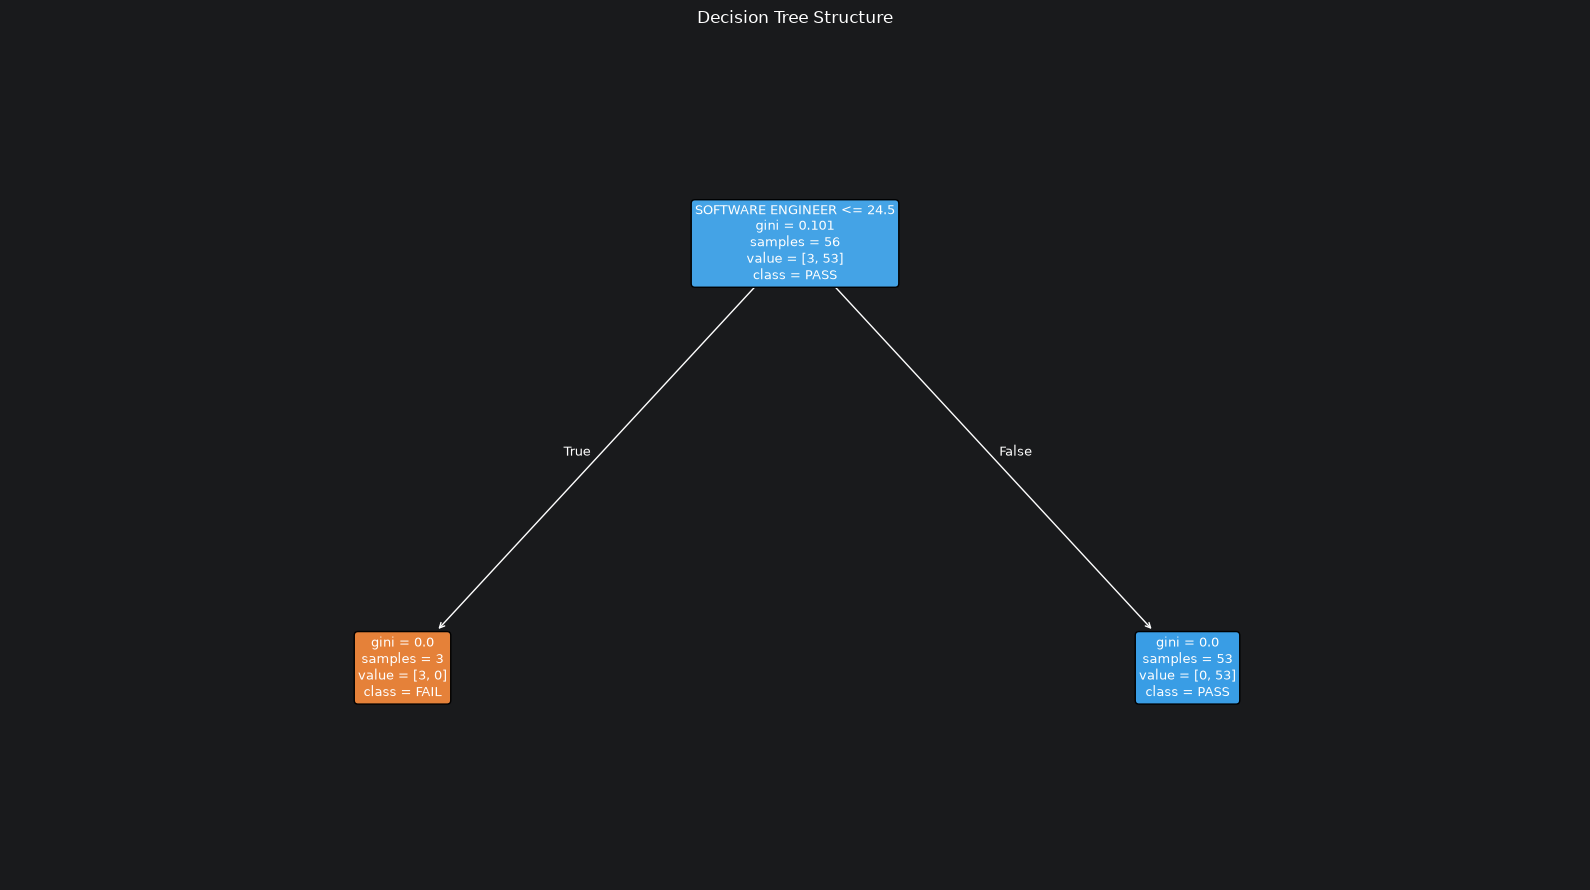

In [7]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 9))
plot_tree(tree_model, feature_names=numeric_cols, class_names=le_result.classes_,
          filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree Structure')
plt.tight_layout()
plt.show()

#### 8. Evaluate the model

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = tree_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_result.classes_, zero_division=0))

Accuracy: 0.9286

Classification Report:
              precision    recall  f1-score   support

        FAIL       0.50      1.00      0.67         1
        PASS       1.00      0.92      0.96        13

    accuracy                           0.93        14
   macro avg       0.75      0.96      0.81        14
weighted avg       0.96      0.93      0.94        14



#### 9. Confusion matrix

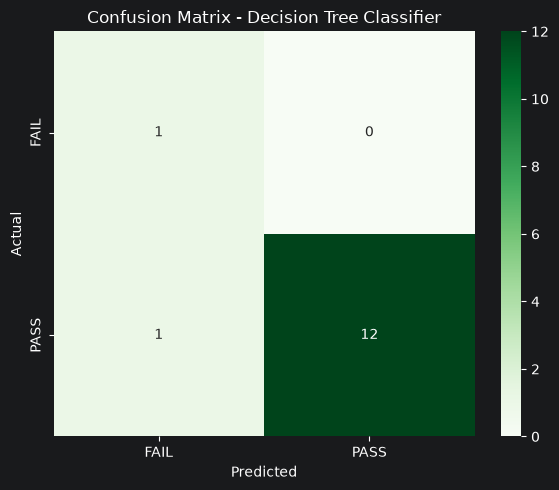

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_result.classes_, yticklabels=le_result.classes_)
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

#### 10. Feature importance

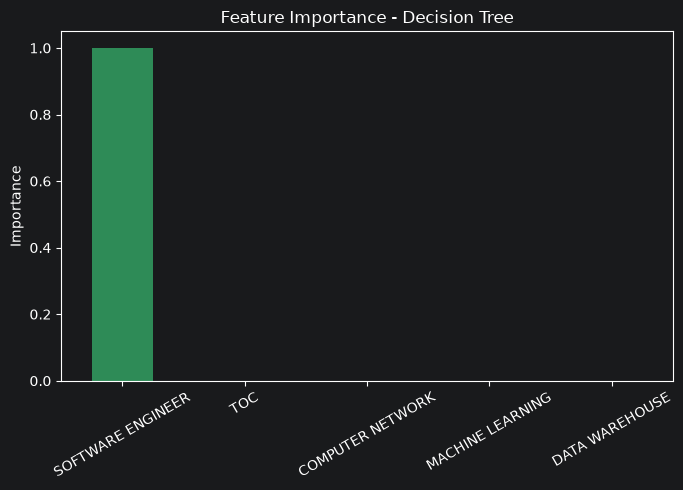

SOFTWARE ENGINEER    1.0
TOC                  0.0
COMPUTER NETWORK     0.0
MACHINE LEARNING     0.0
DATA WAREHOUSE       0.0
dtype: float64


In [10]:
importances = pd.Series(tree_model.feature_importances_, index=numeric_cols).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
importances.plot(kind='bar', color='seagreen')
plt.title('Feature Importance - Decision Tree')
plt.ylabel('Importance')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(importances)

#### 11. Classify a new sample
Use the trained tree to predict the result for a brand-new student, given their subject marks.

In [11]:
# New student's marks, in the same order as numeric_cols
new_sample = pd.DataFrame([[45, 50, 48, 52, 47]], columns=numeric_cols)

prediction = tree_model.predict(new_sample)
prediction_proba = tree_model.predict_proba(new_sample)

print("New sample:")
print(new_sample)
print("\nPredicted RESULT:", le_result.inverse_transform(prediction)[0])
print("Class probabilities:", dict(zip(le_result.classes_, prediction_proba[0])))

New sample:
   SOFTWARE ENGINEER  TOC  COMPUTER NETWORK  MACHINE LEARNING  DATA WAREHOUSE
0                 45   50                48                52              47

Predicted RESULT: PASS
Class probabilities: {'FAIL': np.float64(0.0), 'PASS': np.float64(1.0)}
